# Data Preparation and Exploratory Analysis

## Dataset Overview

The [Thyroid Disease Dataset](https://www.kaggle.com/datasets/emmanuelfwerr/thyroid-disease-data) originates from the UCI Machine Learning Repository and contains patient records with thyroid function measurements.

**Clinical Context:**

The thyroid gland produces hormones (T3, T4) that regulate metabolism. Thyroid dysfunction manifests as:

- **Hyperthyroidism**: Overactive thyroid, excess hormone production (symptoms: weight loss, rapid heart rate, anxiety)
- **Hypothyroidism**: Underactive thyroid, insufficient hormone production (symptoms: fatigue, weight gain, depression)

Key laboratory measurements include:
- **TSH** (Thyroid Stimulating Hormone): High in hypothyroidism, low in hyperthyroidism
- **T3** (Triiodothyronine): Active thyroid hormone
- **T4** (Thyroxine): Main thyroid hormone, measured as TT4 (total) or FTI (Free Thyroxine Index)
- **TBG** (Thyroxine-Binding Globulin): Protein that carries thyroid hormones in blood

## Data Loading & ETL

In this notebook, we perform some **Data Preparation (ETL)**: mainly selecting the columns to use (removing those without useful semantics) and simplifying the target classes. These steps are independent of the data distribution.

This is distinct from **Model Preprocessing** (which we will handle in later notebooks). Preprocessing involves learning from the data (e.g., mean imputation, standard scaling) and **must** be fitted only on the training set to avoid data leakage.

In [1]:
import kagglehub
from pathlib import Path
dataset_path = Path(kagglehub.dataset_download("emmanuelfwerr/thyroid-disease-data"))

/media/DIURNOext4/alejandro/wip-clase/PIA-SAA/example_repos/thyroid/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import pandas as pd
df = pd.read_csv(dataset_path / "thyroidDF.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9172 entries, 0 to 9171
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  9172 non-null   int64  
 1   sex                  8865 non-null   str    
 2   on_thyroxine         9172 non-null   str    
 3   query_on_thyroxine   9172 non-null   str    
 4   on_antithyroid_meds  9172 non-null   str    
 5   sick                 9172 non-null   str    
 6   pregnant             9172 non-null   str    
 7   thyroid_surgery      9172 non-null   str    
 8   I131_treatment       9172 non-null   str    
 9   query_hypothyroid    9172 non-null   str    
 10  query_hyperthyroid   9172 non-null   str    
 11  lithium              9172 non-null   str    
 12  goitre               9172 non-null   str    
 13  tumor                9172 non-null   str    
 14  hypopituitary        9172 non-null   str    
 15  psych                9172 non-null   str    
 16 

The original dataset has over 30 diagnosis categories. We simplify these into three clinically meaningful groups to facilitate model interpretation and reduce class imbalance.

In [3]:
import numpy as np

# Preserve original labels for traceability and idempotency
if "target_raw" not in df.columns:
    df["target_raw"] = df["target"]
df["target"] = np.select(
    [
        df["target_raw"].str.contains("[A-D]", na=False), 
        df["target_raw"].str.contains("[E-H]", na=False)
    ],
    ["hyperthyroid", "hypothyroid"],
    default="negative"
)

print(f"Dataset shape: {df.shape[0]} samples, {df.shape[1]} features")
print("\nTarget distribution:")
display(pd.DataFrame({
    'Count': df['target'].value_counts(),
    'Percentage (%)': (df['target'].value_counts(normalize=True) * 100).round(1)
}))

Dataset shape: 9172 samples, 32 features

Target distribution:


,Count,Percentage (%)
target,,
negative,8264,90.1
hypothyroid,667,7.3
hyperthyroid,241,2.6


The class distribution reveals a significant imbalance: approximately 90% of cases are "negative" (no thyroid dysfunction). This is typical in medical screening datasets where disease prevalence is low. **This imbalance will influence our choice of evaluation metrics** and potentially require specialized handling during model training.

### Dataset Structure & Cleaning

### Feature Types

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9172 entries, 0 to 9171
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  9172 non-null   int64  
 1   sex                  8865 non-null   str    
 2   on_thyroxine         9172 non-null   str    
 3   query_on_thyroxine   9172 non-null   str    
 4   on_antithyroid_meds  9172 non-null   str    
 5   sick                 9172 non-null   str    
 6   pregnant             9172 non-null   str    
 7   thyroid_surgery      9172 non-null   str    
 8   I131_treatment       9172 non-null   str    
 9   query_hypothyroid    9172 non-null   str    
 10  query_hyperthyroid   9172 non-null   str    
 11  lithium              9172 non-null   str    
 12  goitre               9172 non-null   str    
 13  tumor                9172 non-null   str    
 14  hypopituitary        9172 non-null   str    
 15  psych                9172 non-null   str    
 16 

The dataset contains:

- **Numeric features**: `age`, `TSH`, `T3`, `TT4`, `T4U`, `FTI`, `TBG` (continuous measurements)
- **Binary features**: Most non-numeric columns are binary categorical with values "f" and "t", representing "false" and "true", respectively, such as `on_thyroxine`, `pregnant`, `thyroid_surgery`. These columns can be converted to numeric binary variables (0 and 1) to facilitate their use in the model.
- **Categorical features**: `sex` (M/F). This column has ~300 missing values. Because Pandas stores string columns as `object` types, these missing values are represented as `np.nan` (floating-point numbers). This type-mixing (strings + floats) will require explicit string-casting in our modeling pipelines to prevent type-checking errors in libraries like CatBoost.
- **Measurement flags**: Each numeric test has a corresponding `_measured` column indicating whether the test was performed.
- **patient_id** is an identifier that does not provide relevant information, so they will be removed.
- **referral_source** (values like SVI, SVHC, STMW, SVHD) indicates where the patient came from (e.g., a specific clinic, a general practitioner, or another hospital department). 

`referral_source` can be predictive due to a prior probability (Patients referred from a specialized "Thyroid Clinic" (STMW) might have a 50% chance of being sick, whereas patients from a "General Checkup" source (SVI) might only have a 1% chance.). Even though it's not a biological symptom, it changes the "Base Rate." A Logistic Regression or Tree can use this to adjust its starting probability.

However, it is not causal and specific to this dataset. We are going to assume that our model should predict in a different environment and focus on the biological data.

In [5]:
df.drop(columns=['patient_id', 'referral_source'], inplace=True)

## Defining evaluation metric

Standard accuracy is misleading for this dataset due to the ~90% "negative" class. A model predicting "negative" for every patient would achieve ~90% accuracy while being clinically useless.

In medical screening, the primary goal is to **minimize False Negatives**.

* **Recall (Sensitivity):** Measures, "Out of all the patients who actually have the disease, how many did we successfully find?"

**The Clinical Scenario:** If a patient has thyroid disease but the model classifies them as "negative" (low recall), they might go untreated, leading to severe health complications.

**The Trade-off:** High recall often comes at the cost of lower precision (more False Positives). In this domain, a False Positive usually just means the patient undergoes an unnecessary blood test—a relatively low cost compared to the dangers of a missed diagnosis.

Therefore, we should prioritize the following metrics instead of baseline accuracy:

1. **Recall (Sensitivity) for the Sick Classes:** This should be the primary constraint (e.g., requiring Recall > 98%).
2. **F1-Score:** If you need a single metric to balance the trade-off, F1 is far better than accuracy. As the harmonic mean of Precision and Recall, it punishes the model heavily if either metric drops too low.
3. **AUC-ROC / PR-AUC:** These curves are standard in medical ML literature because they illustrate how well the model separates classes across all possible decision thresholds.

For this experiment, we will implement a custom **Thyroid Mean Recall**, which averages the recall of the two specific disease classes:

$$\text{Score} = \frac{\text{Recall}_{\text{hyperthyroid}} + \text{Recall}_{\text{hypothyroid}}}{2}$$

This ensures equal focus on detecting both thyroid conditions, regardless of their individual dataset prevalences.

> **TODO: The "Trivial Model Problem"**
> Relying solely on Recall introduces a mathematical trap. If a custom scorer *only* evaluates Recall, an optimization process (like `GridSearchCV`) can exploit it by predicting every single patient as sick, maximizing the score while ignoring Precision entirely. In production, the standard solution is to balance this trade-off using a **Macro $F_2$ Score**. (Note: While the empirical recall in our specific XGBoost experiment is slightly lower with $F_2$, it is mathematically safer to prevent the algorithm from abandoning precision).

### Reproducibility Note: The Loading Function

To ensure these exact cleaning steps are reproducible across our future modeling notebooks, we have encapsulated the logic above (loading, target simplification, and dropping identifiers) into a dedicated utility function:

`src.data_loader.load_thyroid_data_3_classes`

along with the training/test split. This function will be the entry point for all subsequent experiments, ensuring uniform data quality.

## Exploratory Data Analysis

Now that we have a clean, structured dataset, we proceed to **EDA** on the full dataset to understand its properties and inform our preprocessing strategy.

### Numeric Feature Distributions

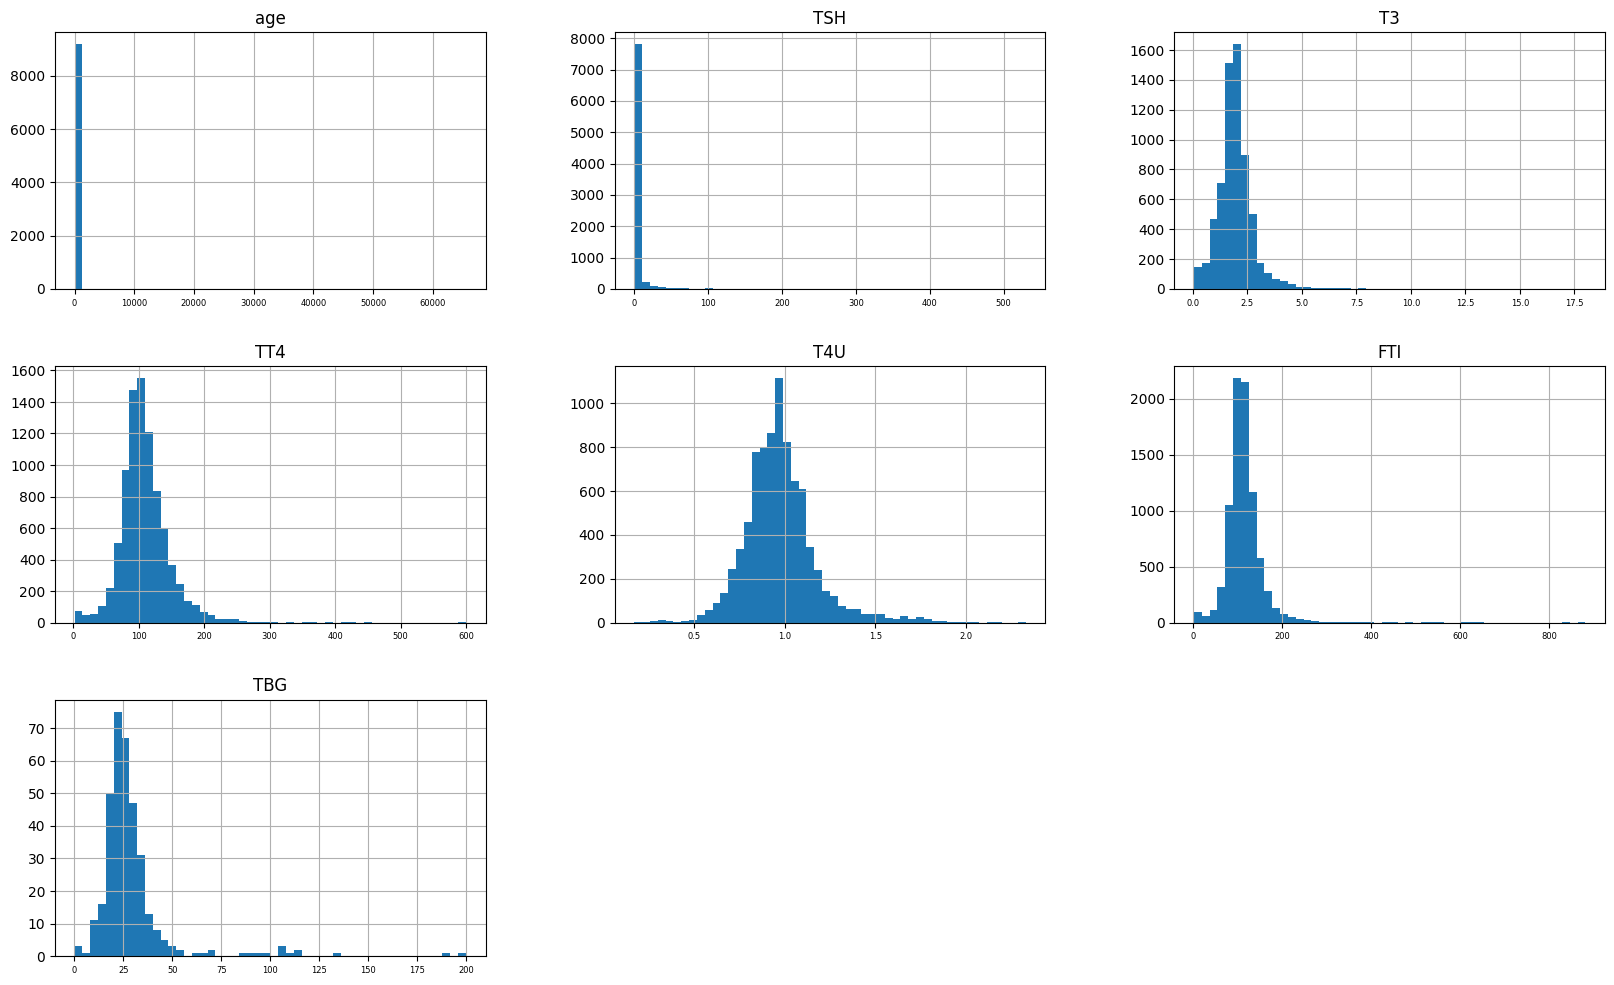

In [6]:
import matplotlib.pyplot as plt
_ = df.hist(bins=50, figsize=(20, 12), xlabelsize=6) 

- Data Integrity & Outliers: The age distribution contains egregious data entry errors, with maximum values exceeding 60,000. These impossible values indicate clerical errors that require threshold-based filtering (e.g., capping age at 100).

- Skewness & Transformation: TSH exhibits extreme right-skewness, with the vast majority of density clustered near zero and a long tail extending to 500+. This suggests a non-normal baseline where a log-transformation will be necessary to stabilize variance for linear models.

- Gaussian Features: The thyroid function markers (T3, TT4, T4U, and FTI) approximate normal distributions. This is expected in medical test metrics with most samples negative: it represents the population, **normally** patients will have metrics around the mean, and extreme measurements are infrequent and often will be disease indicators. However, TT4 and FTI retain visible right-sided outliers, which likely represent genuine pathological (hyperthyroid) cases rather than noise.

- Feature Sparsity: The TBG histogram displays negligible frequency counts compared to the other features (max count ~70 vs ~8000), confirming that this variable suffers from massive missingness and is likely unsuitable for modeling.

### Age Treatment

In [7]:
# Values of age over 100
df[df['age'] > 100]

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_meds,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG,target,target_raw
2976,455,F,f,f,f,f,f,f,f,f,...,t,118.0,t,1.13,t,104.0,f,NaN,negative,-
5710,65511,M,f,f,f,f,f,f,f,f,...,t,113.0,t,1.08,t,104.0,f,NaN,negative,-
6392,65512,M,f,f,f,f,f,f,f,f,...,t,112.0,t,0.84,t,133.0,f,NaN,negative,-
8105,65526,F,f,f,f,f,f,f,f,f,...,t,132.0,t,1.02,t,129.0,f,NaN,negative,-


<Axes: >

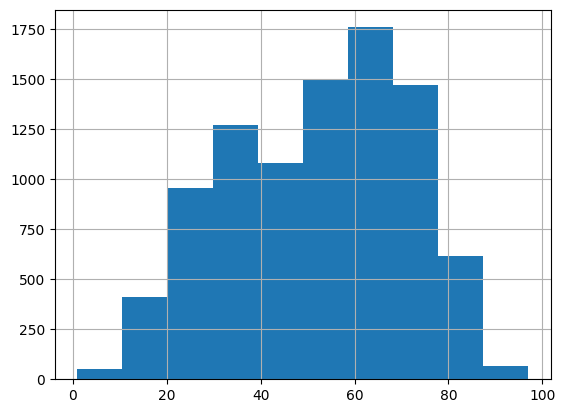

In [8]:
df[df['age'] < 100]['age'].hist()

We see that there are 4 rows with absurd age values that will therefore be considered data entry errors, so they will be treated as missing values. Once these values are removed, the age distribution is quite symmetric and has no outliers.

In [9]:
df.loc[df['age'] > 100, 'age'] = np.nan 

We still will have to decide how to treat missing age values (imputation vs. leave as NaN) based on the model choice.


### TSH Treatment

Max Age is now: 97.0
TSH skewness before: 12.92
TSH skewness after log: 1.94


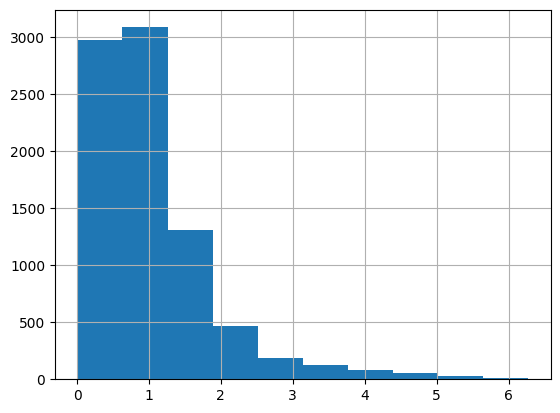

In [10]:
# We apply a log transformation. 
# We add +1 because log(0) is undefined, and TSH can be 0.
# Formula: TSH_log = log(TSH + 1)
df['TSH_log'] = np.log1p(df['TSH'])
print(f"Max Age is now: {df['age'].max()}")
print(f"TSH skewness before: {df['TSH'].skew():.2f}")
print(f"TSH skewness after log: {df['TSH_log'].skew():.2f}")

_ = df['TSH_log'].hist()

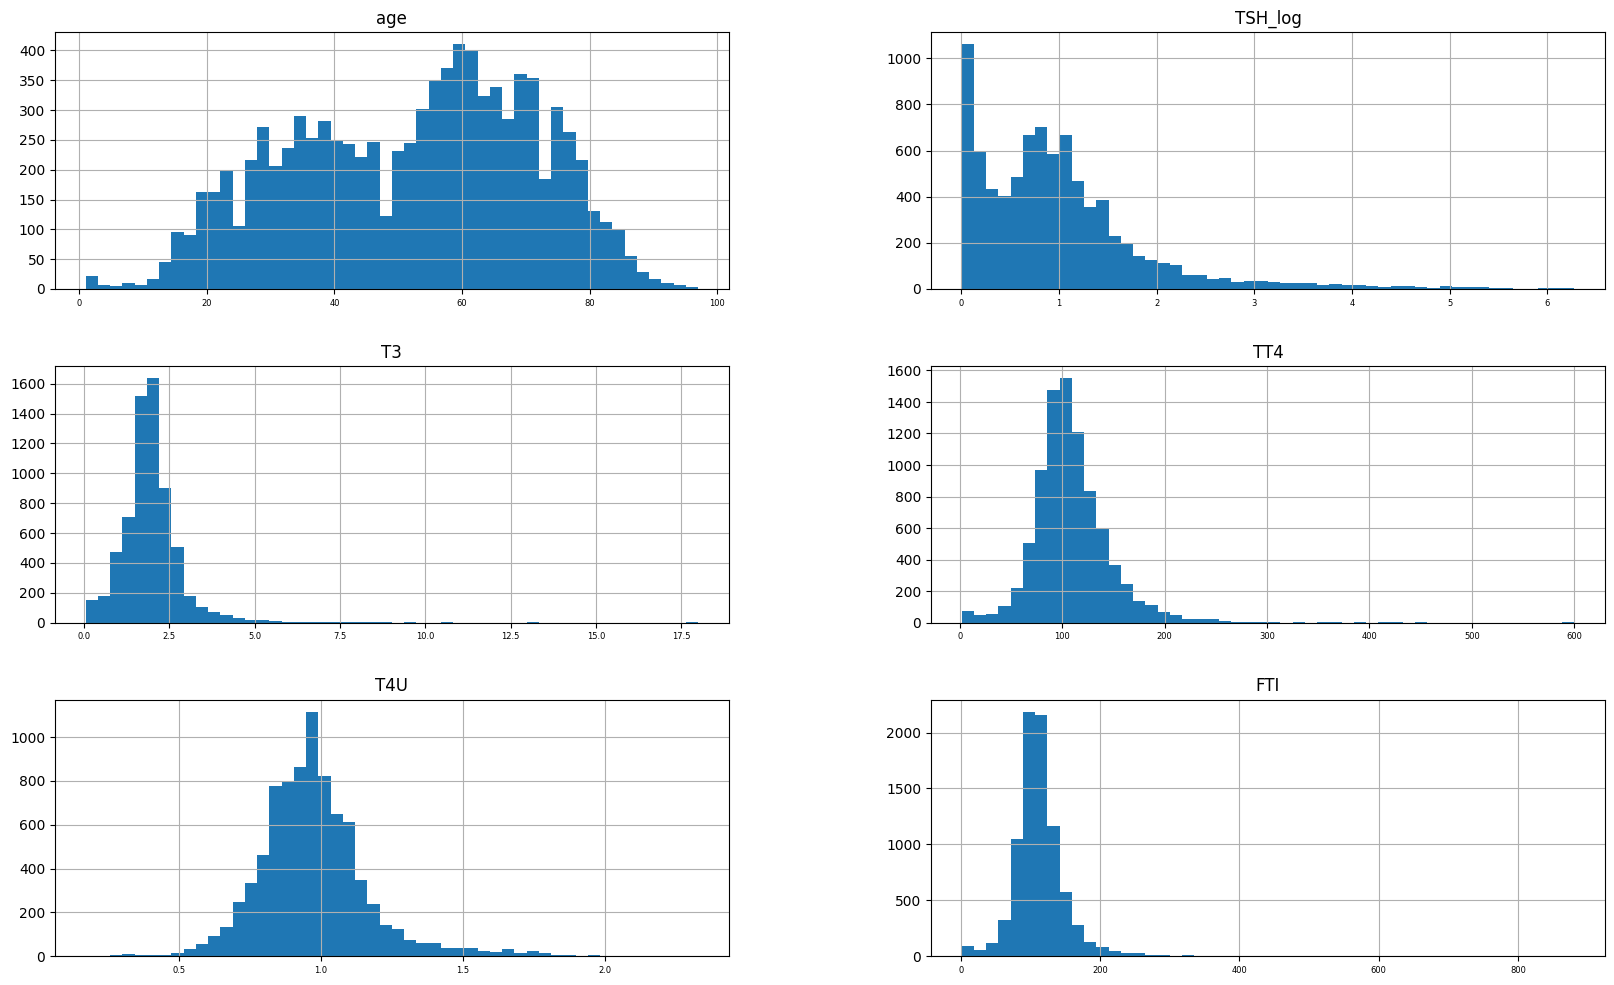

In [11]:
cleaned_cols = ['age', 'TSH_log', 'T3', 'TT4', 'T4U', 'FTI']
_ = df[cleaned_cols].hist(bins=50, figsize=(20, 12), xlabelsize=6) 

## Missing Value Analysis

In [12]:
missing_counts = df.isnull().sum()
missing_percentages = (df.isnull().sum() / len(df) * 100).round(1)

missing_df = pd.DataFrame({
    'missing_count': missing_counts,
    'missing_percentage': missing_percentages
})

missing_df[missing_df['missing_count'] > 0].sort_values('missing_percentage', ascending=False)

,missing_count,missing_percentage
TBG,8823,96.2
T3,2604,28.4
TSH_log,842,9.2
TSH,842,9.2
T4U,809,8.8
FTI,802,8.7
TT4,442,4.8
sex,307,3.3
age,4,0.0


### Understanding Missingness Patterns

Not all missing values are created equal. In this dataset, we distinguish between two fundamental mechanisms that require different handling strategies:

#### 1. "Informative Missingness" (TBG - Thyroxine-Binding Globulin)
*   **Missing Rate:** Extreme (>90%).
*   **Mechanism:** **MNAR (Missing Not At Random)**. The missingness itself is a feature.
    *   **Context:** Doctors do not order this expensive test for standard patients. It is typically a "tie-breaker" ordered only when basic tests (T3/T4) are contradictory or borderline.
    *   **The Trap:** The few values we *do* have likely suffer from **Selection Bias** (skewed toward complex/sick cases). Imputing the remaining 90% based on this skewed minority would introduce significant noise.
*   **Strategy:** **Value = Irrelevant, Flag = Critical.**
    *   We trust the *absence* of the test more than a guessed value.
    *   **Action:** Drop the numeric column (or impute a placeholder like 0/-1) and rely on the `TBG_measured` binary flag to capture the "doctor's intuition."

#### 2. "Incidental Missingness" (T3, TSH, T4)
*   **Missing Rate:** Moderate (~10-30%).
*   **Mechanism:** **MAR (Missing At Random)**.
    *   **Context:** These are standard panel tests. If T3 is missing, it is often because T4/TSH were sufficient for a diagnosis (a predictable clinical rule), or due to random lab issues. The missingness is likely explained by other observed variables (like T4 levels).
*   **Strategy:** **Value = Critical, Flag = Redundant.**
    *   We believe these patients *have* a "normal" or "predictable" value that we just didn't measure.
    *   **Action:** Impute the value (using Median or Grouped Imputation by Sex) to restore the biological picture. The `_measured` flag is less useful here and can be dropped for tree-based models.


### Measurement Flags Analysis

In [13]:
# Verify relationship between _measured flags and NaN values
measured_cols = [col for col in df.columns if col.endswith('_measured')]

for col in measured_cols:
    base_col = col.replace('_measured', '')
    if base_col in df.columns:
        measured_true = (df[col] == 't').sum()
        has_value = df[base_col].notna().sum()
        print(f"{base_col}: measured='t' count = {measured_true}, non-null count = {has_value}")

TSH: measured='t' count = 8330, non-null count = 8330
T3: measured='t' count = 6568, non-null count = 6568
TT4: measured='t' count = 8730, non-null count = 8730
T4U: measured='t' count = 8363, non-null count = 8363
FTI: measured='t' count = 8370, non-null count = 8370
TBG: measured='t' count = 349, non-null count = 349


We verified that the `_measured` flags correctly indicate missing values in the corresponding numeric features. For example, if `TSH_measured` is 0, then `TSH` is NaN. This means that the flags are logically redundant: they contain the same missingness information already encoded by `NaN` in the numeric column.

However, whether the flags should be dropped depends on the **model family** and the **missing-value strategy**, because after preprocessing the redundancy can disappear:

- **If you impute numeric values (Logistic Regression, most linear models):**
  - Once you impute, the numeric column no longer contains `NaN`, so the model loses the information that “this value was originally missing”.
  - In that case, a `_measured` flag can add useful signal, because it preserves the missingness pattern separately from the imputed value. This is exactly the rationale behind sklearn’s SimpleImputer(add_indicator=True), which explicitly adds missing indicators so a downstream estimator can use missingness as signal. However, in this case, the information is already present in the `_measured` columns, so we can just keep those instead of adding new indicators.

- **If the model handles `NaN` natively (Random Forest in Scikit-learn ≥ 1.4, XGBoost/CatBoost):**
  - Keeping both the numeric feature with `NaN` *and* the `_measured` flag is usually redundant.
  - Recommended: keep the numeric feature as `NaN` and **drop** `_measured` flags (including `TBG_measured`), unless you want explicit interpretability about “test ordered”.

- **Special case: TBG**
  - Even though `TBG_measured` is redundant with `NaN` *before* preprocessing, it may be the **most meaningful** representation of TBG in this dataset, since the “test was ordered” event can be more informative than any imputed TBG value (informative missingness / selection bias).

- **Neural networks**
  - NNs cannot consume `NaN` directly, so imputation is mandatory; therefore keeping `_measured` flags is typically a good idea (acts like a mask / missingness cue) to avoid treating imputed values as real measurements.

### Feature Distributions by Class (Cleaned Data)

Now we visualize the distributions relative to the target class.

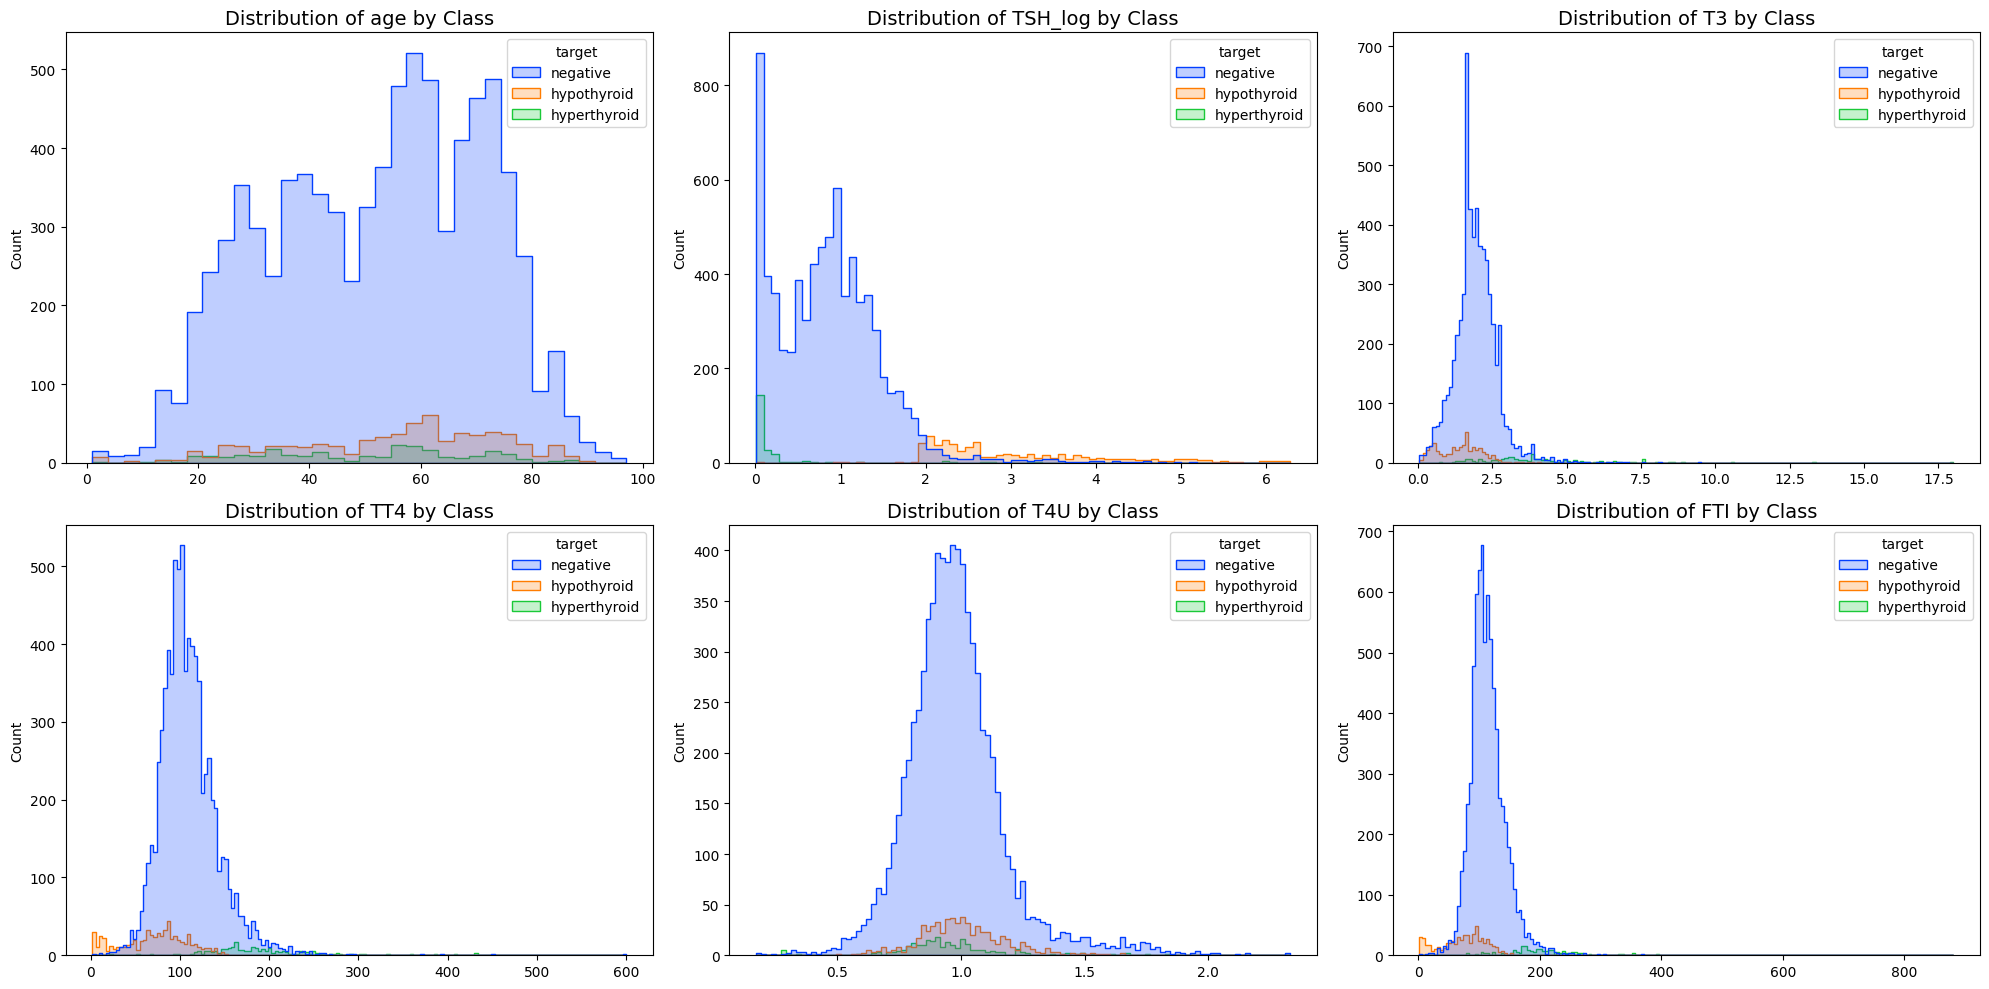

In [14]:
from src.visualization import plot_histograms_by_class
plot_histograms_by_class(df, target_col='target', columns=cleaned_cols)

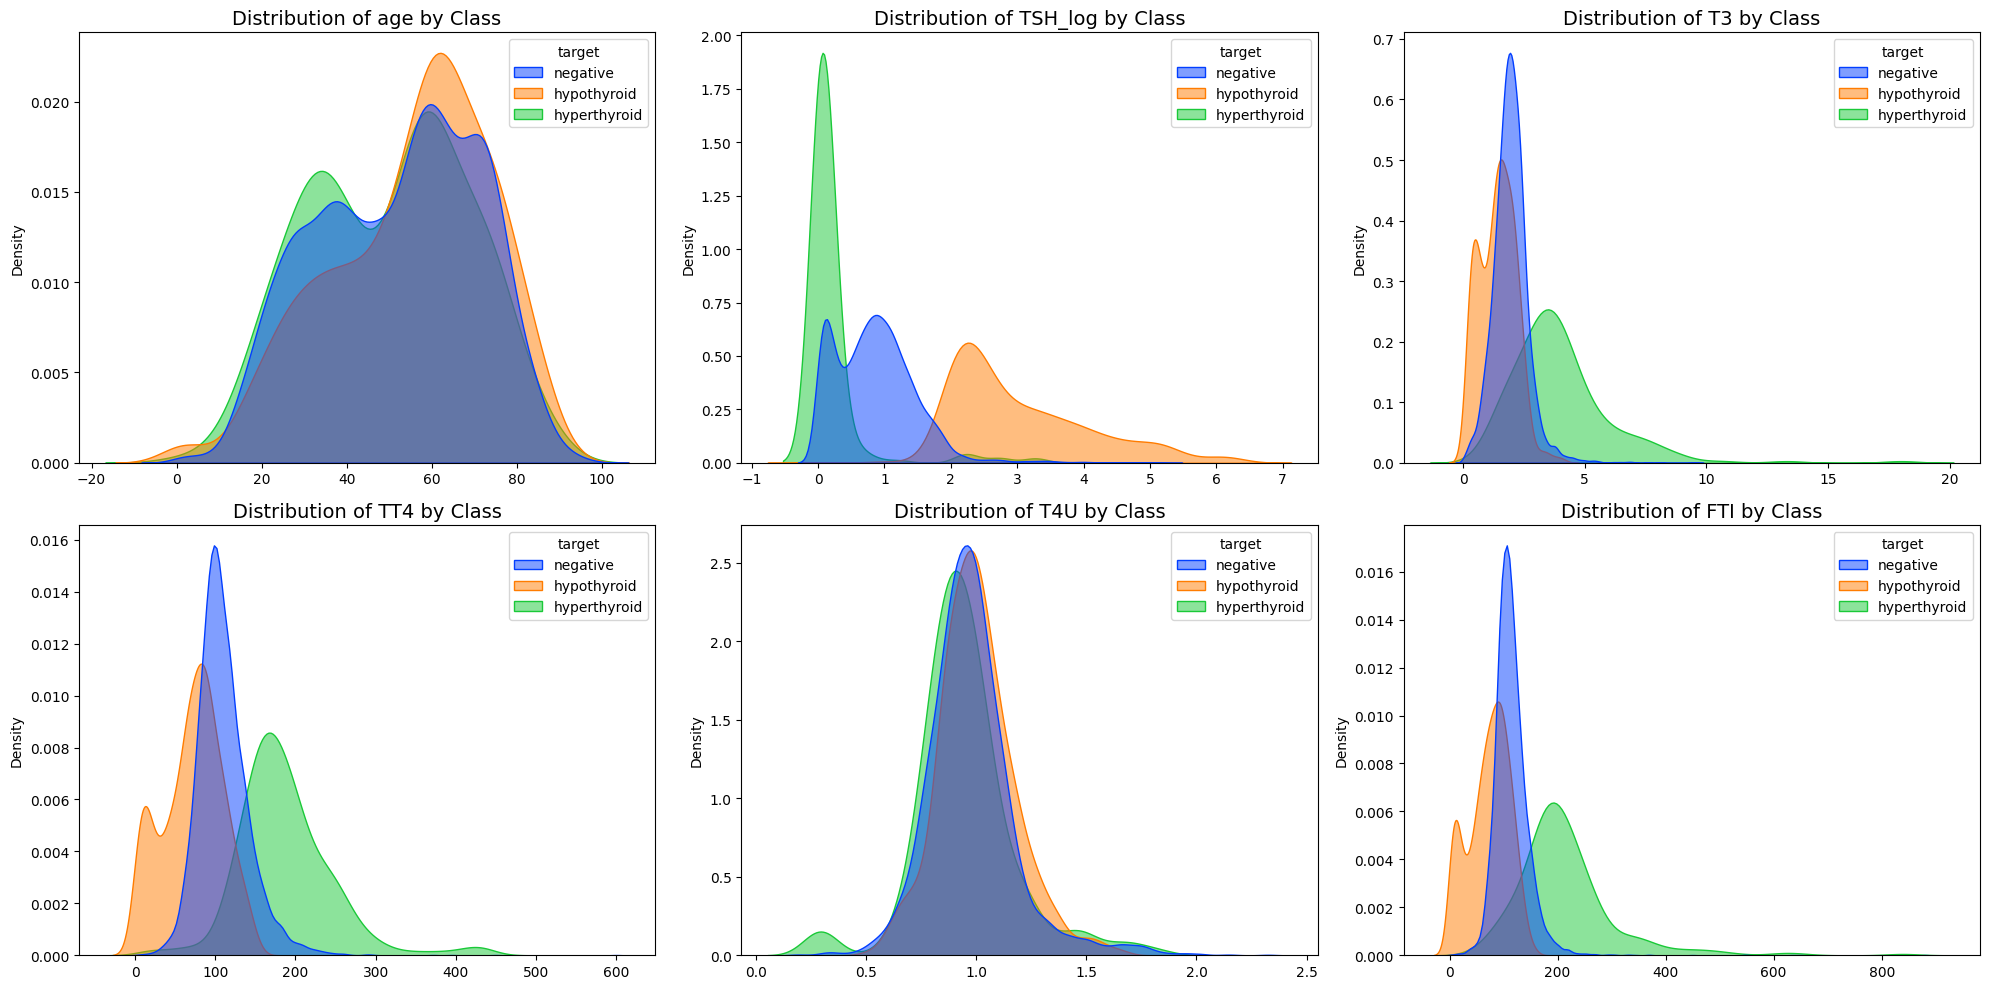

In [15]:
from src.visualization import plot_histograms_by_class
plot_histograms_by_class(df, target_col='target', columns=cleaned_cols, kde=True)

### Analysis of Feature Distributions by Class

In this section, we analyze how the feature distributions differ across the three diagnostic classes (`Negative`, `Hypothyroid`, `Hyperthyroid`). This step is critical for identifying which features possess the strongest **discriminative power** for our model.

#### A Note on Visualization: Histograms vs. KDE
We present two views of the data to handle the extreme class imbalance in this dataset:

1.  **Raw Histograms:** These show the *absolute counts*. While truthful, the massive number of "Negative" cases (thousands) visually drowns out the pathological cases (often fewer than 100), making the "Hyperthyroid" class appear as barely visible noise.
2.  **Kernel Density Estimation (KDE):** This visualizes the *probability density* (shape) of the data rather than raw counts. Think of it as smoothing the histogram blocks into a continuous curve.
    * **Why it helps here:** We use independent normalization (`common_norm=False`). This scales the area of the "Hyperthyroid" curve to match the "Negative" curve, allowing us to compare the **location and shape** of the distributions as equals, regardless of their sample size.

#### Key Insights from the Analysis
* **Strongest Predictors (Separation):**
    * **TSH (Log-Transformed):** Shows the clearest separation. The **Hypothyroid** class forms a distinct cluster at the high end, while **Hyperthyroid** cases are compressed near zero (suppressed).
    * **FTI & TT4:** Exhibit a strong inverse relationship to TSH. **Hyperthyroid** patients shift significantly to the right (elevated levels), while **Hypothyroid** patients shift left (depressed levels).
* **Weak Predictors (Overlap):**
    * **Age & T4U:** These features show significant topological overlap. The density curves for sick and healthy patients are nearly identical, suggesting that age and T4U levels alone are not reliable indicators of thyroid disease status in this population.

## Correlation Analysis

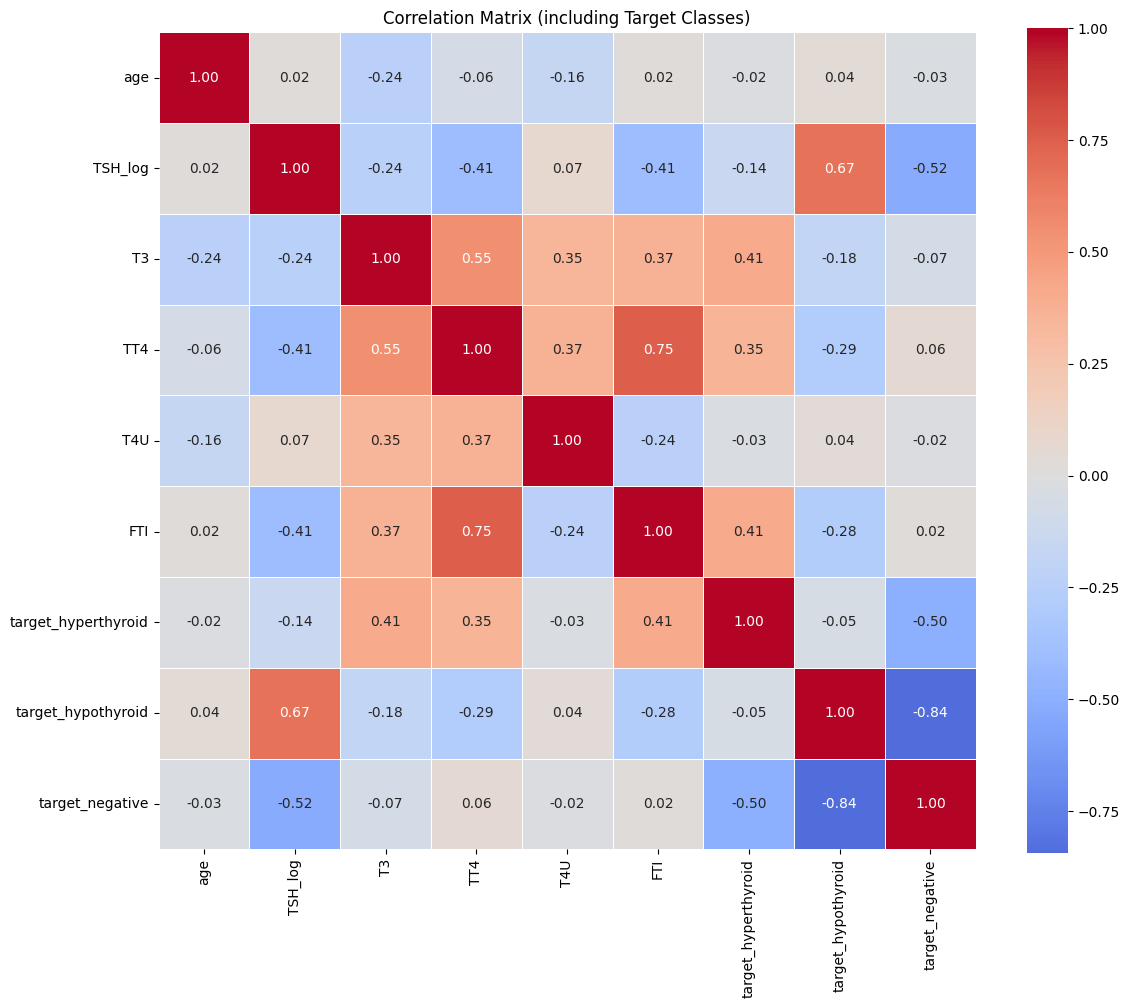

In [16]:
import seaborn as sns

# Create dummy variables for target classes
target_dummies = pd.get_dummies(df['target'], prefix='target').astype(int)

# Add dummies to features for correlation analysis
df_corr = pd.concat([df[cleaned_cols], target_dummies], axis=1)
correlation_matrix = df_corr.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Correlation Matrix (including Target Classes)')
plt.tight_layout()
plt.show()

### Interpretation of Correlations

Analyzing these correlations helps us anticipate model behavior and validate data quality:

1.  **Multicollinearity (TT4 & FTI)**:
    - **Observation:** These features are extremely highly correlated (> 0.9).
    - **Why it matters:** FTI is mathematically derived from TT4. For linear models (Logistic Regression), this redundancy can destabilize coefficient estimates. Tree-based models are robust to this, but we should be aware that feature importance might be split between them.

2.  **Diagnostic Signals (Target Correlations)**:
    - **TSH vs. Hypothyroid:** We expect a **positive correlation**. Biologically, high TSH indicates the pituitary is screaming at an underactive thyroid.
    - **T3/TT4 vs. Hyperthyroid:** We expect a **positive correlation**. Hyperthyroidism is defined by excess production of these hormones.
    - **T3/TT4 vs. Hypothyroid:** We expect a **negative correlation** (hormone deficiency).

3.  **Age Factor**:
    - **Observation:** Age often shows weak linear correlation with specific classes.
    - **Implication:** While not a standalone diagnostic marker like TSH, Age is clinically relevant as prevalence varies by life stage. Its value likely comes from **interactions** (e.g., TSH levels might have different thresholds in older adults).

## Key Insights for Preprocessing

Based on our exploratory analysis, we identified several preprocessing requirements:

1. **Class Imbalance**: ~92.5% negative cases require careful metric selection (Recall/F1) and stratified splitting.
2. **Feature Engineering Needs**:
    - **TSH**: Highly skewed, benefits from log transformation.
    - **Age**: Contains physical impossibilities (>100). Requires outlier clipping or removal.
    - **TBG**: The numeric column is ~96% missing and should be dropped. However, the `TBG_measured` flag contains valuable signal and must be retained as a predictor.
    - **Missing Values**: T3, T4, and FTI have moderate missingness that is likely Missing At Random (MAR), suitable for imputation.

These specifications form the requirements for the **Preprocessing Pipeline** we will build in the next notebook.